In [1]:
# Alex Medina
# AST 5765 
# Final Project
# 8 November 2025

In [29]:
##### IMPORTS
import os
import numpy as np
import gaussian as g
import astropy.io.fits as fits
import matplotlib.pyplot as plt

from astropy.stats import sigma_clip

In [3]:
print('Problem 1) \n')
print('Completed on log. \n')

Problem 1) 

Completed on log. 



In [4]:
print('Problem 2) \n')
print('Completed on log. \n')

Problem 2) 

Completed on log. 



In [5]:
print('Problem 3 \n')

Problem 3 



In [31]:
##### VARIABLES
datadir = 'data/'
fext    = '.fits'

datafiles = []

for filename in os.listdir(datadir): # for creation of another variable
    if filename.startswith('SPITZER'):
        file =filename.split(fext)[0]
        datafiles.append(file)

datafiles = sorted(datafiles)
nfiles    = len(datafiles)

# Column indices in the photometry array
setnum_col     = 0  # number of SPITZER file
fnumber_col    = 1  # local frame number (within SPITZER file)
glob_index_col = 2  # global frame number (over all files)
MJD_col        = 3  # mid-time of the frame (MJD, days)
medbkg         = 4  # background value
ycenter        = 5  # y center fit
xcenter        = 6  # x center fit


In [7]:
print(datadir)

data/


In [8]:
print('Problem 4 \n')

Problem 4 



In [9]:
# ROUTINE for files

# a) Read first block for relevant information
infofile   = fits.getdata(datadir + datafiles[0] + fext)
nf, nx, ny = infofile.shape
print(f'The number of frames per file: {nf} frames')

# b) Datacube and photometry array to save important numbers
totframes  = nfiles * nf
datacube   = np.zeros((totframes, nx, ny))
print(f'The shape of the datacube: {datacube.shape}')

nparams   = 7  # parameter indexes listed in variables
photometry  = np.zeros((totframes, nparams))
print(f'The shape of the photometry array: {photometry.shape}')

# c) Main routine
def read_sets(startset, endset, datacube, photarr):
    """
    Loop over SPITZER frames starting at a given global subarray set number (frame index) and ending at another (inclusive).

    Parameters
    startset : int
        global frame number from which to begin allocating data
    endset : int
        global frame number from which to end allocating data
    datacube : np.array
        empty datacube to store data
    photarr : np.array
        array to store photometry numbers
    
    Results
    completed datacube and updated photometry array
    """
    # Start and end set
    print(f"Reading frames {startset} through {endset}.")

    # Cache the last file it doesn't read same file 64 times
    current_index = None
    datablock     = None
    hdr           = None

    for global_frame_index in range(startset, endset + 1):
        # Find SPITZER file where global frame exists
        # i.e., 187 // 64 = 2, means global frame 187 is in SPITZER
        # file 3 because index 2, also file 3 has frames (128 through 191)
        file_index = global_frame_index // nf

        # Within the SPITZER file, the local file number
        # i.e., 187 % 64, is 187.62 is 2 with remainder is 59,
        # so it's the 60th frame in in the SPITZER file
        local_frame_index = global_frame_index % nf

        # Load new file when file_index changes
        if file_index != current_index:
            current_index = file_index
            # i) read data and header
            datablock, hdr = fits.getdata(datadir + datafiles[file_index] + fext, header=True)

            # Print every 10th file (not frame) we touch in this range
            # Which means we only get 2 print statments for whole set
            if (file_index - (startset // nf)) % 10 == 0:
                print(f'{datafiles[file_index]} : DATE_OBS = {hdr["DATE_OBS"]}')

            framtime  = hdr['FRAMTIME']  # interval between frames in a set
            exptime   = hdr['EXPTIME']   # duration of one exposure (s)
            mjd_start = hdr['MJD_OBS']   # start of first frame (days)

            # Take half exptime and add to a time keyword(mjd_start) to get midtime of first frame
            t0 = mjd_start + (0.5 * exptime) / 86400  # days

        # ii) Put science data into the 3D datacube
        datacube[global_frame_index, :, :] = datablock[local_frame_index, :, :]

        # iii) Subsequent images separated by framtime after t0
        mid_time = t0 + local_frame_index * ( framtime / 86400 )  # days

        # Filling photometry array
        photarr[global_frame_index, setnum_col]     = file_index
        photarr[global_frame_index, fnumber_col]    = local_frame_index
        photarr[global_frame_index, glob_index_col] = global_frame_index
        photarr[global_frame_index, MJD_col]        = mid_time

    return datacube, photarr

The number of frames per file: 64 frames
The shape of the datacube: (1536, 32, 32)
The shape of the photometry array: (1536, 7)


In [10]:
print('Problem 5 \n')

Problem 5 



Reading frames 187 through 686.
SPITZER_I4_20674048_0102_0000_2_bcd : DATE_OBS = 2006-10-28T23:55:32.373


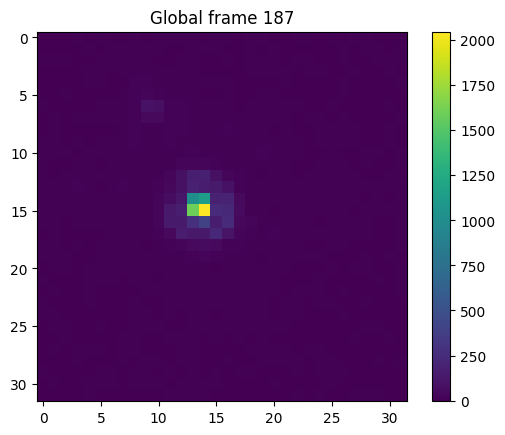

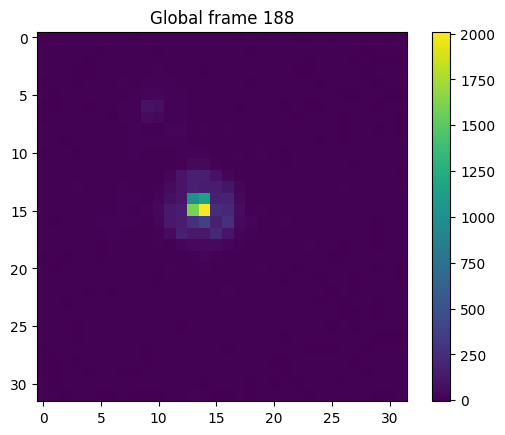

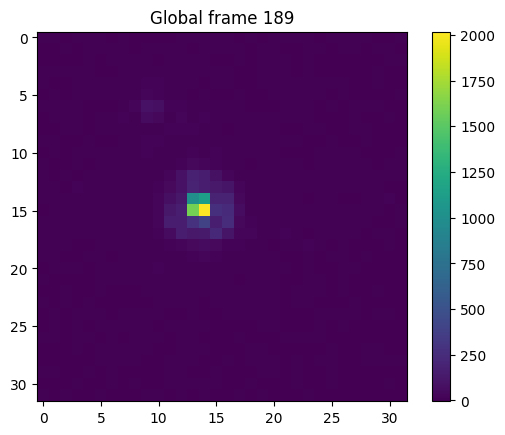

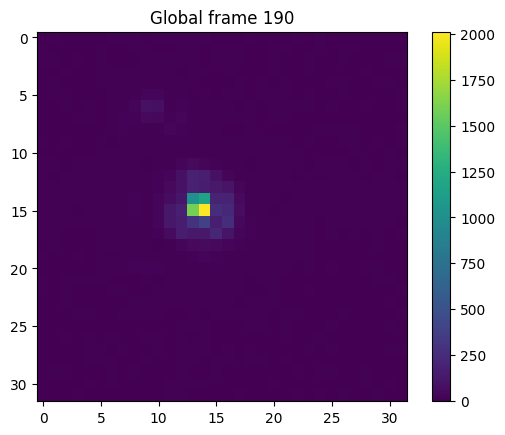

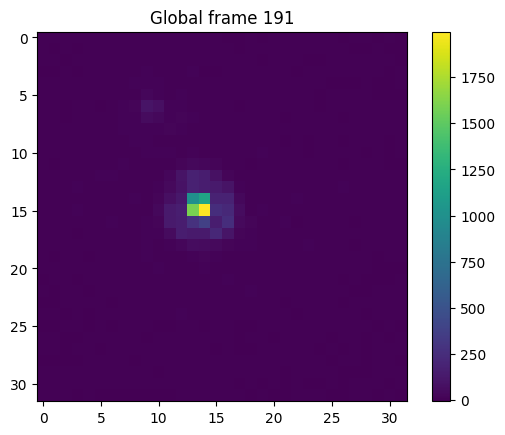

Reading frames 0 through 1535.
SPITZER_I4_20674048_0100_0000_2_bcd : DATE_OBS = 2006-10-28T23:54:37.795
SPITZER_I4_20674048_0110_0000_2_bcd : DATE_OBS = 2006-10-28T23:59:11.669
SPITZER_I4_20674048_0120_0000_2_bcd : DATE_OBS = 2006-10-29T00:03:45.685


In [30]:
# Run the function, starting at subarray set 0187 and ending at 0686 (inclusive)

startset5 = 187
endset5   = 686
datacube5, photometry5 = read_sets(startset5, endset5, datacube, photometry)

# Looking at first few frames
# Only running when this true
inspect_p5 = True

if inspect_p5:
    for i in range(startset5, startset5 + 5):
        plt.figure()
        plt.imshow(datacube5[i, :, :])
        plt.colorbar()
        plt.title(f'Global frame {i}')
        plt.show()

    # Check that you do not have blank frames at the end of your data array
    #tail_means = datacube[-:].mean(axis=(1, 2))
    #print("Mean of last 10 frames in datacube:", tail_means)

    #blank_frames = np.where(np.all(datacube == 0.0, axis=(1, 2)))[0]
    #print("Indices of completely blank frames (if any):", blank_frames[-20:])

# For the rest of the assignment, using all frames
startset = 0
endset   = 1535
datacube, photometry = read_sets(startset, endset, datacube, photometry)

In [12]:
print('Problem 6 \n')

Problem 6 



In [13]:
# Boolean mask array thats the same shape as data array
# True = good pixel, False = bad pixel
# Initialize to true using np.ones
mask = np.ones_like(datacube, dtype=bool)

In [14]:
print('Problem 7 \n')

Problem 7 



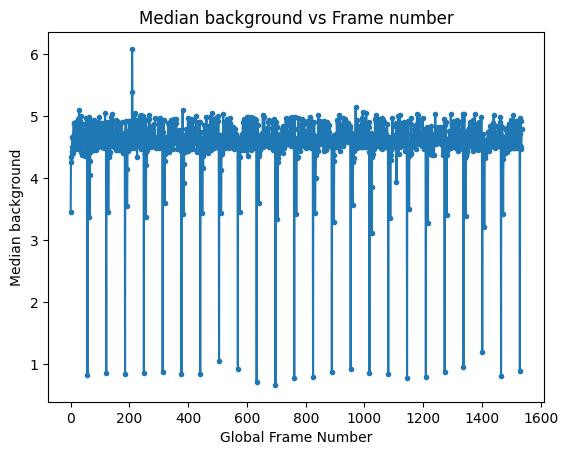

In [15]:
# Median value in each frame
# I suppose because from inspection most of the image is sky

for i in range(totframes):
    med = np.median(datacube[i, :, :])
    photometry[i, medbkg] = med
    datacube[i, :, :]    -= med # subtract median

# Background vs frame number
plt.figure()
plt.plot(photometry[:, medbkg], marker='.')
plt.xlabel("Global Frame Number")
plt.ylabel("Median background")
plt.title("Median background vs Frame number")
plt.show()


In [16]:
print('Problem 8 \n')

Problem 8 



In [23]:
# Sigma-rejection routine

def sigma_reject(data, sigma, iters):
    """
    Sigma-rejection

    Parameters
    data : np.array
        data array
    sigma : int or float
        sigma
    iters : int or float
        number of iterations
    
    Returns
        Boolean array where True = good pixel, False = bad pixel.
    """
    clipped = sigma_clip(data, sigma=sigma, maxiters=iters, masked=True)
    # clipped values are returned as True, but those are the bad
    # so the good mask is the non-clipped values
    good_mask = ~clipped.mask
    return np.asarray(good_mask)


In [24]:
print('Problem 9 \n')

Problem 9 



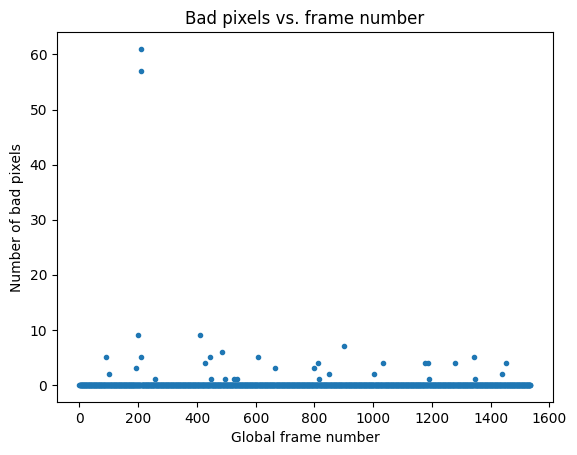

In [27]:
# Find bad pixels

# First loop steps by jumps of 64
for f0 in range(0, totframes, nf):
    f63 = f0 + nf # end index (exclusive) for this block
    # Second and third loops over y and x
    for y in range(ny):
        for x in range(nx):
            # Extract each set of 64 pixels (1 from each frame) at same y, x
            extract = datacube[f0:f63, y, x]

            # Sigma reject on each set
            good = sigma_reject(extract, 5.0, 2)

            # Insert resulting boolean into mak array
            mask[f0:f63, y, x] &= good

# From problem 8, all bad pixels not in current mask are flagged as 0
# To not account for bad pixels
datacube[~mask] = 0

# Bad pixels vs frame number
bad_counts = (~mask).sum(axis=(1, 2))

plt.figure()
plt.plot(np.arange(totframes), bad_counts, marker='.', linestyle='none')
plt.xlabel("Global frame number")
plt.ylabel("Number of bad pixels")
plt.title("Bad pixels vs. frame number")
plt.show()


In [28]:
print('Problem 10 \n')

Problem 10 



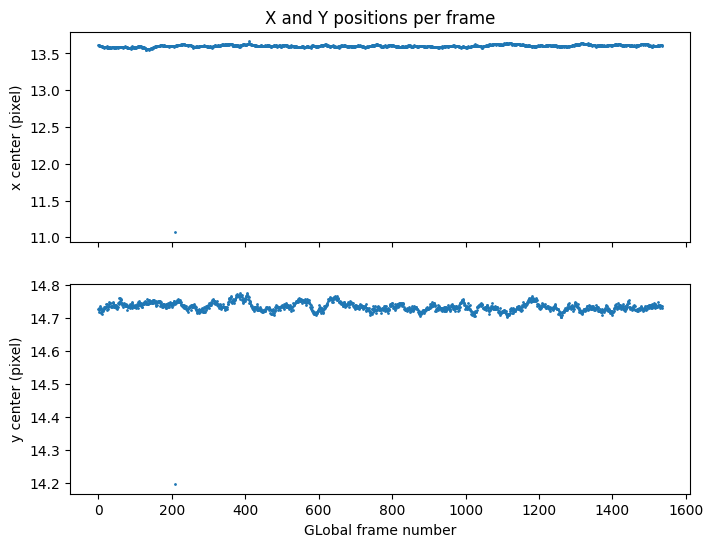

In [37]:
# Approximate location of center of star routine

def fitcenter(frame, yguess, xguess, subz):
    """
    Fit 2D Gaussian around guess

    Parameters
    
    center : (yguess, xguess)
    """

    # Subarray
    yg, xg = int(yguess), int(xguess)

    ytop = yg + subz + 1
    ybot = yg - subz
    xtop = xg + subz + 1
    xbot = xg - subz

    sub = frame[ybot:ytop, xbot:xtop].copy()
    sub -= np.median(sub) # median sub

    # Fitting relative to subarr (width tuple) (center tuple) (height)
    guess = ((2.0, 2.0), (yg - ybot, xg - xbot), np.max(sub))

    # Gaussian fit
    fw, fc, fh, fe = g.fitgaussian(sub, guess=guess)

    # Fitting back to original coords
    cy, cx = float(fc[0] + ybot), float(fc[1] + xbot)

    return cy, cx
    
# For the first frame, viually its about y, x = 15, 14
frame0 = datacube[0, :, :]
y0, x0 = 15, 14
cy0, cx0 = fitcenter(frame0, y0, x0, 6) # say subz = 6 for now
photometry[0, ycenter] = cy0
photometry[0, xcenter] = cx0

# Looping over all imtages, using previous fitted position as guess
for i in range(1, totframes):
    framei = datacube[i, :, :]
    yi, xi = photometry[i-1, ycenter], photometry[i-1, xcenter]
    cyi, cxi = fitcenter(framei, yi, xi, 6)
    photometry[i, ycenter] = cyi
    photometry[i, xcenter] = cxi

# Plot x and y position vs the frame number
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 6))

ax1.plot(photometry[:, xcenter], '.', ms=2)
ax1.set_ylabel('x center (pixel)')
ax1.set_title('X and Y positions per frame')
ax2.plot(photometry[:, ycenter], '.', ms=2)
ax2.set_ylabel('y center (pixel)')
ax2.set_xlabel('GLobal frame number')
plt.show()

In [34]:
print('Problem 11 \n')

Problem 11 



In [38]:
# --- Build a median image over all frames ---
median_image = np.median(datacube, axis=0)

# --- Find approximate location of program star (brightest source) ---
y_prog_guess, x_prog_guess = np.unravel_index(np.argmax(median_image), median_image.shape)

# Refine program star center on the median image
cy_prog_med, cx_prog_med = fitcenter(median_image, y_prog_guess, x_prog_guess, subz=6)

# --- Find approximate location of the fainter companion ---
# Mask out a small box around the program star to find the next brightest source
temp = median_image.copy()
r_box = 6  # half-size of the box to blank around the primary

y0b = int(cy_prog_med)
x0b = int(cx_prog_med)
temp[y0b - r_box:y0b + r_box + 1, x0b - r_box:x0b + r_box + 1] = np.min(temp)

y_comp_guess, x_comp_guess = np.unravel_index(np.argmax(temp), temp.shape)

# Refine companion center on the median image
cy_comp_med, cx_comp_med = fitcenter(median_image, y_comp_guess, x_comp_guess, subz=6)

# --- Compute and print offsets (companion relative to program star) ---
dy = cy_comp_med - cy_prog_med
dx = cx_comp_med - cx_prog_med

print(f"Companion - primary offset: Δy = {dy:.3f} pixels, Δx = {dx:.3f} pixels")

# --- Mask the companion star in each frame ---
# Precompute pixel grid for distance calculation
yy, xx = np.indices((median_image.shape[0], median_image.shape[1]))

r_mask = 4.0  # radius of disk to mask around the companion (in pixels)

for i in range(totframes):
    # Program star center for this frame
    cy = photometry[i, ycenter]
    cx = photometry[i, xcenter]

    # Companion center using the constant offset
    cy_comp = cy + dy
    cx_comp = cx + dx

    # Distance-squared from companion center
    dist2 = (yy - cy_comp)**2 + (xx - cx_comp)**2

    # Mask: mark pixels within radius as bad (False)
    mask[i, dist2 <= r_mask**2] = False


Companion - primary offset: Δy = -8.547 pixels, Δx = -4.197 pixels


In [35]:
print('Problem 12 \n')

Problem 12 



In [ ]:
print('Problem 13 \n')